In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..

In [2]:
import os
import pandas as pd
from impl.config import CONFIG
from impl.utils.visualization import visualize_archived_solutions_by_gen, visualize_archive_solution_over_generations

def list_files_between(directory, start_file, end_file=None):
    files = sorted(os.listdir(directory))
    start_index = files.index(start_file) if start_file in files else None
    if end_file is None:
        end_index = len(files) - 1
    else:
        end_index = files.index(end_file) if end_file in files else None

    if start_index is None or end_index is None:
        raise ValueError("Start file or end file not found in the directory")

    if start_index > end_index:
        start_index, end_index = end_index, start_index
    
    return [os.path.join(directory, file) for file in files[start_index:end_index + 1]]

def read_table_string(table_string):
    header = [col.strip() for col in table_string.strip().split('\n')[0].split('|')[1:-1]]
    rows = [row.split('|')[1:-1] for row in table_string.strip().split('\n')[2:]]
    rows = [[element.strip() for element in row] for row in rows]
    df = pd.DataFrame(rows, columns=header)
    return df

/home/hossein/PycharmProjects/automatic-potato/.venv/lib/python3.7/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [3]:
decreasing_cp_table = """
| Solution/Statistics | Start checkpoint | End checkpoint |
| :------------------ | :--------------- | :------------- |
| ccea-1727209526466  | 1727201519649    | 1727209525799  |
| ccea-1727240994672  | 1727235598273    | 1727240994238  |
| ccea-1727266901005  | 1727261716665    | 1727266900474  |
| ccea-1727295192682  | 1727288292889    | 1727295192277  |
| ccea-1727323277274  | 1727316247139    | 1727323276634  |
| ccea-1727350900214  | 1727343419222    | 1727350899632  |
| ccea-1727380354661  | 1727373922607    | 1727380353945  |
| ccea-1727411465615  | 1727403610820    | 1727411465040  |
| ccea-1727439594179  | 1727432664046    | 1727439593383  |
| ccea-1727469833556  | 1727462943800    | 1727469832790  |
| ga-1727222567297    | 1727209911905    | 1727222566366  |
| ga-1727250570553    | 1727241404211    | 1727250570021  |
| ga-1727277786075    | 1727267613418    | 1727277785562  |
| ga-1727305247085    | 1727295908578    | 1727305246414  |
| ga-1727332417742    | 1727323806097    | 1727332417270  |
| ga-1727360236396    | 1727351350346    | 1727360235858  |
| ga-1727391457944    | 1727380896561    | 1727391457305  |
| ga-1727421077088    | 1727412055217    | 1727421076474  |
| ga-1727450998141    | 1727440319781    | 1727450997411  |
| ga-1727480862318    | 1727470376451    | 1727480861750  |
| rs-1727232907851    | 1727223364731    | 1727232907448  |
| rs-1727259420090    | 1727251274947    | 1727259419608  |
| rs-1727286578674    | 1727278306501    | 1727286578130  |
| rs-1727314239612    | 1727306232310    | 1727314239208  |
| rs-1727341179646    | 1727333077420    | 1727341179299  |
| rs-1727369189391    | 1727360732518    | 1727369188866  |
| rs-1727401251184    | 1727392085249    | 1727401250811  |
| rs-1727430452614    | 1727421643803    | 1727430452209  |
| rs-1727460765043    | 1727451559666    | 1727460764631  |
| rs-1727490053161    | 1727481385453    | 1727490052651  |
"""

dec_cps = read_table_string(decreasing_cp_table)
dec_cps['alg'] = dec_cps['Solution/Statistics'].apply(lambda x: x.split('-')[0])

CP_BASE = 'out/server_checkpoints'
# CP_BASE = CONFIG["workspace"]["checkpoint"]

In [4]:
checkpoints = {}
for i, row in dec_cps.iterrows():
    alg = row['alg']
    if alg not in checkpoints:
        checkpoints[alg] = []
    run = list_files_between(CP_BASE, f"{row['Start checkpoint']}.pickle", f"{row['End checkpoint']}.pickle")
    checkpoints[alg].append(run)

pygame 2.1.2 (SDL 2.0.16, Python 3.7.16)
Hello from the pygame community. https://www.pygame.org/contribute.html


/home/hossein/PycharmProjects/automatic-potato/.venv/lib/python3.7/site-packages/deap/creator.py:188: RuntimeWarning: A class named 'Fitness' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  RuntimeWarning)
/home/hossein/PycharmProjects/automatic-potato/.venv/lib/python3.7/site-packages/deap/creator.py:188: RuntimeWarning: A class named 'Solution' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  RuntimeWarning)
/home/hossein/PycharmProjects/automatic-potato/.venv/lib/python3.7/site-packages/deap/creator.py:188: RuntimeWarning: A class named 'Scenario' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  RuntimeWarning)
/home/hossein/PycharmProjects/automatic-potato/.venv/lib/python3.7/site-packages/deap/creator.py:188: RuntimeWarning: A class named 'Perturbation' has already been cre

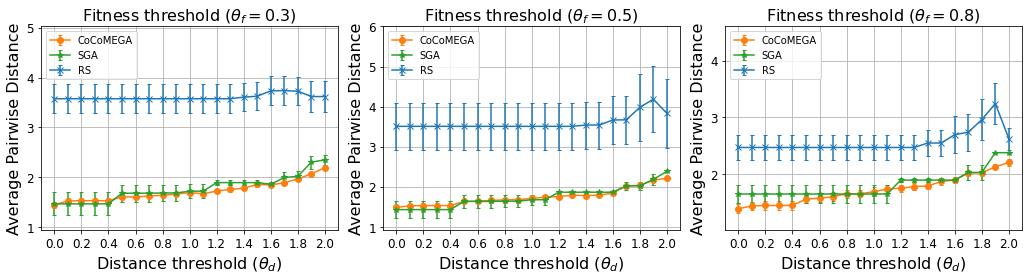

In [5]:
distance_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

df = visualize_archived_solutions_by_gen(checkpoints, generation_num=7, metric_name='avg_pw', fitness_thresholds=[0.3, 0.5, 0.8],
                                          distance_thresholds=distance_thresholds, box=False, show=True, legend_loc='upper left')

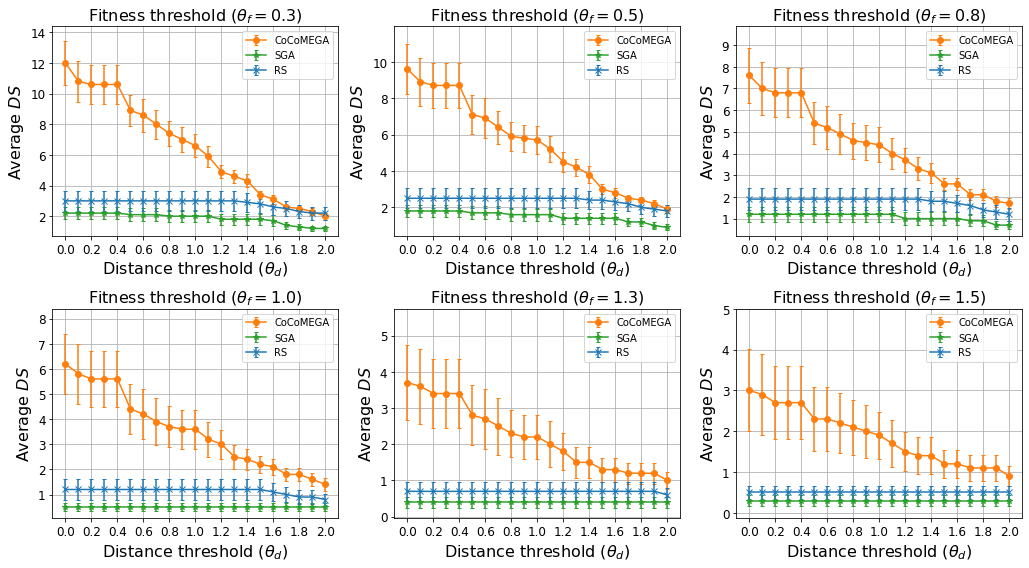

In [6]:
df = visualize_archived_solutions_by_gen(checkpoints, generation_num=7, metric_name='distinct_solution_num',
                                         fitness_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
                                          distance_thresholds=distance_thresholds, box=False, show=True)

# Archive Solutions Over Generations

In [7]:
checkpoints = {}
for i, row in dec_cps.iterrows():
    alg = row['alg']
    if alg not in checkpoints:
        checkpoints[alg] = []
    checkpoints[alg].append((row["Start checkpoint"], row["End checkpoint"]))

df = visualize_archive_solution_over_generations(directory=CP_BASE, files=checkpoints, metric_name='avg_pw',
                                                 fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.3, 0.5, 0.8],
                                                 max_gen=7, show=True, legend_loc='upper right')

NameError: name 'visualize_archive_solution_over_generations' is not defined